/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Device: cuda
Dataset root: /kaggle/input/acne04

DATASET STATISTICS
Total images: 1377
Class distribution:
  Class 0:  483 ( 35.1%)
  Class 1:  623 ( 45.2%)
  Class 2:  175 ( 12.7%)
  Class 3:   96 (  7.0%)

Train/Val/Test: 1101/138/138

Class weights: [0.7130829  0.55271083 1.9660715  3.5746753 ]

AVAILABLE MODELS
  mobilenet_v2         - MobileNetV2 (Fast, Lightweight)
  efficientnet_b0      - EfficientNet-B0 (Probably Best Accuracy)
  resnet34             - ResNet34 (Balanced)

QUICK MODEL COMPARISON

Trying mobilenet_v2...


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 79.2MB/s]


  → Val F1: 0.5079

Trying efficientnet_b0...


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  → Val F1: 0.3431

Trying resnet34...


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 206MB/s]
[I 2025-12-15 09:10:06,976] A new study created in memory with name: no-name-023fceef-3dd8-4b85-b8c6-bdcf2ff44709


  → Val F1: 0.4933

Best Model: mobilenet_v2 (F1: 0.5079)

HYPERPARAMETER OPTIMIZATION (15 trials)


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2025-12-15 09:11:47,394] Trial 0 finished with value: 0.44117336971458565 and parameters: {'lr': 0.00023409229440146375, 'batch_size': 32, 'dropout': 0.3898504911556816, 'weight_decay': 1.4209532296366824e-05, 'use_focal': True, 'gamma': 1.145737300318749}. Best is trial 0 with value: 0.44117336971458565.
[I 2025-12-15 09:13:28,772] Trial 1 finished with value: 0.5410372703500334 and parameters: {'lr': 0.0008446135315062274, 'batch_size': 16, 'dropout': 0.12102921817589883, 'weight_decay': 3.843452141724324e-05, 'use_focal': False}. Best is trial 1 with value: 0.5410372703500334.
[I 2025-12-15 09:15:07,974] Trial 2 finished with value: 0.5044197671003041 and parameters: {'lr': 0.0021376170291824356, 'batch_size': 32, 'dropout': 0.268911330523614, 'weight_decay': 5.126847164994441e-05, 'use_focal': True, 'gamma': 2.481783029404588}. Best is trial 1 with value: 0.5410372703500334.
[I 2025-12-15 09:16:48,076] Trial 3 finished with value: 0.530647904981141 and parameters: {'lr': 0.00042

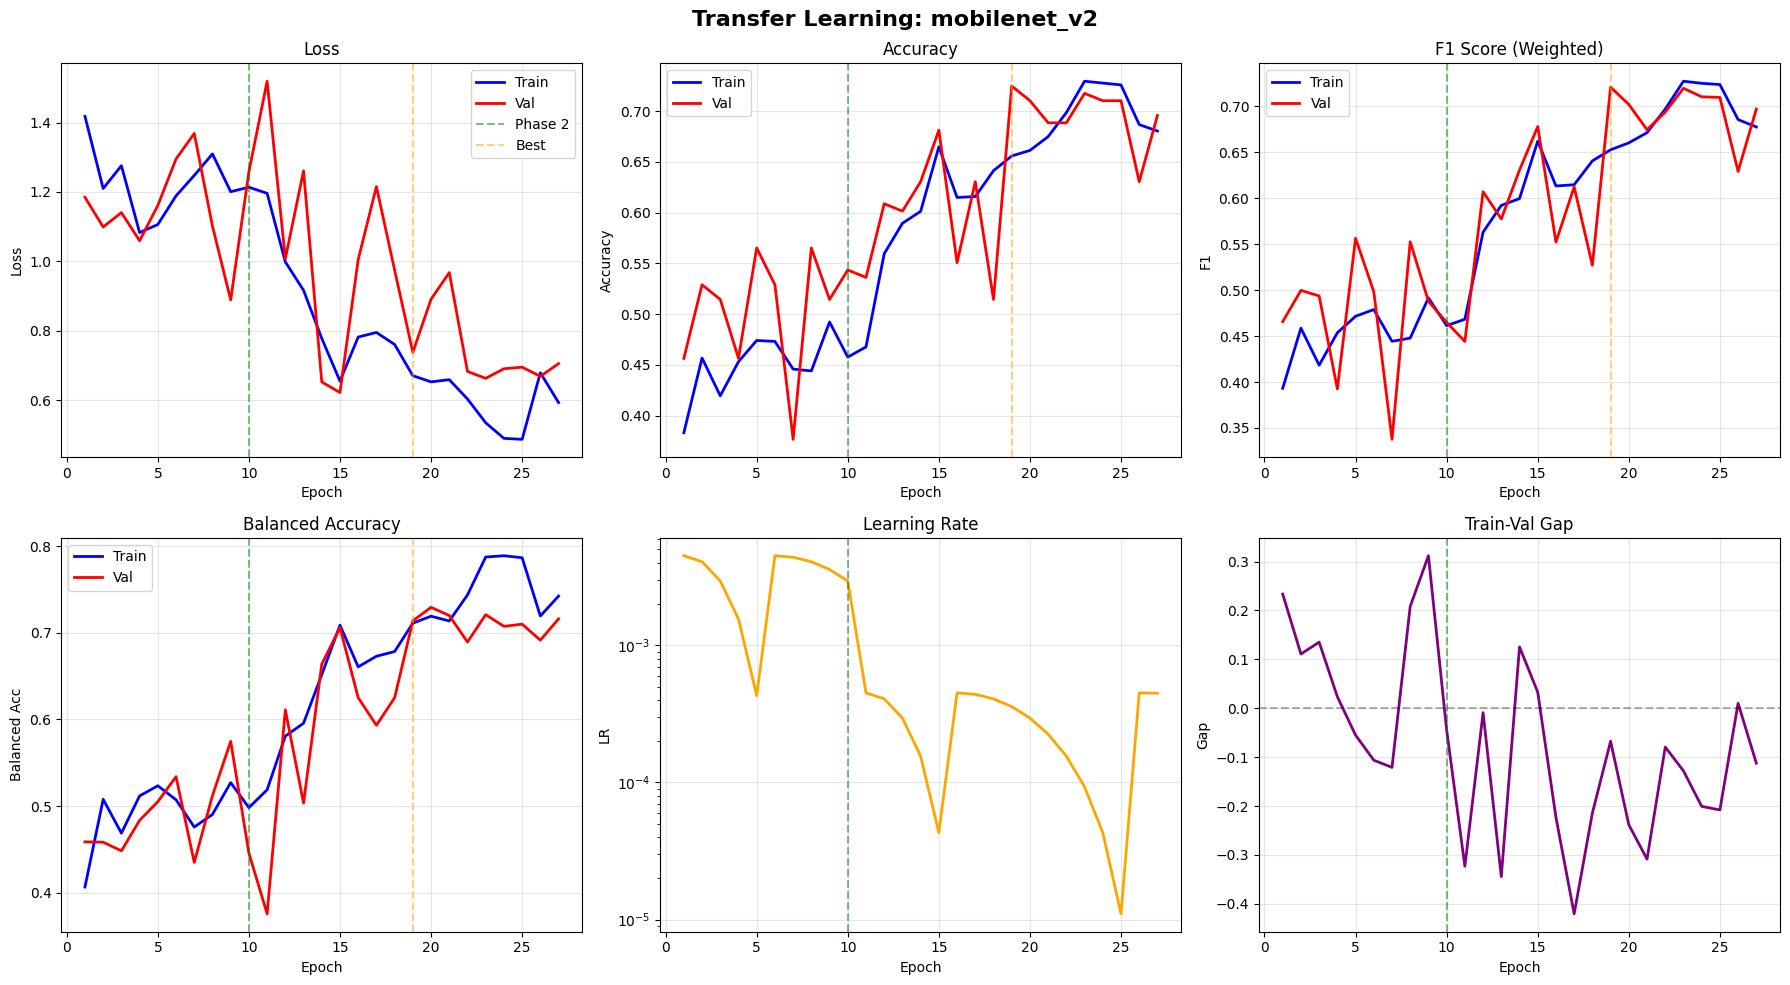


TEST SET EVALUATION

Standard Testing:
  Accuracy: 0.7899
  Balanced Accuracy: 0.7118
  F1 (weighted): 0.7873
  F1 (macro): 0.7106

Test Time Augmentation (TTA):
  TTA Accuracy: 0.7681 (Δ-0.0217)
  TTA F1: 0.7648 (Δ-0.0226)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7377    0.9184    0.8182        49
     Class 1     0.8654    0.7258    0.7895        62
     Class 2     0.6667    0.6667    0.6667        18
     Class 3     0.5714    0.4444    0.5000         9

    accuracy                         0.7681       138
   macro avg     0.7103    0.6888    0.6936       138
weighted avg     0.7750    0.7681    0.7648       138



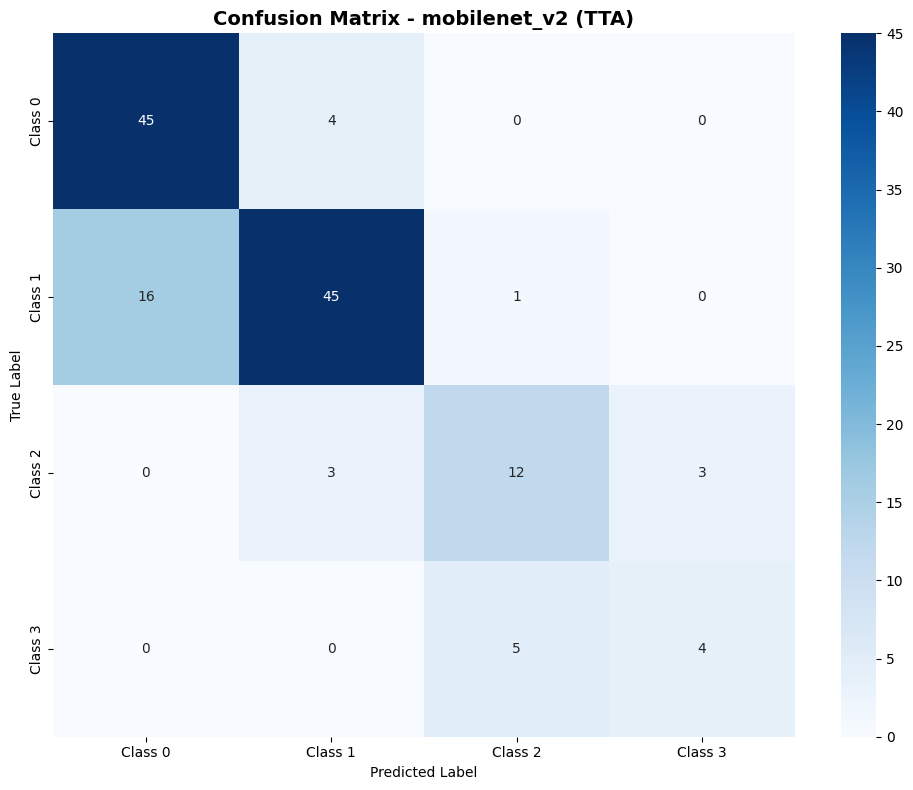


PER-CLASS METRICS
Class 0 (n=49): Acc=0.9184, Precision=0.7377, Recall=0.9184, F1=0.8182
Class 1 (n=62): Acc=0.7258, Precision=0.8654, Recall=0.7258, F1=0.7895
Class 2 (n=18): Acc=0.6667, Precision=0.6667, Recall=0.6667, F1=0.6667
Class 3 (n= 9): Acc=0.4444, Precision=0.5714, Recall=0.4444, F1=0.5000

FINAL SUMMARY
Model: mobilenet_v2
Best Epoch: 19
Best Val F1: 0.7206
Test Accuracy (standard): 0.7899
Test Accuracy (TTA): 0.7681
Test F1 (TTA): 0.7648

Files saved:
  - mobilenet_v2_best.pth
  - mobilenet_v2_checkpoint.pt
  - training_history.json
  - training_curves.png
  - confusion_matrix_tta.png


/kaggle/working/mobilenet_v2_best.pth

/kaggle/working/mobilenet_v2_checkpoint.pt

In [1]:
# =========================================
# Transfer Learning 
# MobileNetV2, EfficientNet, ResNet50
# =========================================

import importlib, sys, subprocess

def ensure_pkg(pkg):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure_pkg("optuna")
ensure_pkg("timm") 

# =========================================
# Imports
# =========================================
import os, re, json, math, random, gc, warnings
from pathlib import Path
from collections import Counter

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

import timm  

import optuna
from optuna.pruners import MedianPruner

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    f1_score, precision_score, recall_score, balanced_accuracy_score
)

warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================
# Dataset Loading
# =========================================
def find_dataset_root():
    candidates = [Path("/kaggle/input/acne04"), Path("../input/acne04")]
    for c in candidates:
        if c.exists():
            return c
    import kagglehub
    return Path(kagglehub.dataset_download("manuelhettich/acne04"))

root = find_dataset_root()
print("Dataset root:", root)

IMG_EXTS = {".jpg", ".jpeg", ".png"}
FOLDER_RE = re.compile(r"acne([0-3])_1024$", re.IGNORECASE)
LABEL_RE  = re.compile(r"(?:levle|level)([0-3])_", re.IGNORECASE)

def find_image_mode(root: Path):
    for p0 in root.rglob("acne0_1024"):
        parent = p0.parent
        ok = all((parent / f"acne{i}_1024").exists() for i in [1,2,3])
        if ok:
            return ("folders", [parent / f"acne{i}_1024" for i in [0,1,2,3]])
    for p in root.rglob("all_1024"):
        return ("all", p)
    raise FileNotFoundError("Dataset not found")

mode, where = find_image_mode(root)

def infer_label(path: Path):
    m = FOLDER_RE.match(path.parent.name)
    if m:
        return int(m.group(1))
    m = LABEL_RE.search(path.name)
    if m:
        return int(m.group(1))
    return None

def collect_samples(mode, where):
    samples = []
    if mode == "folders":
        for d in where:
            for fp in d.rglob("*"):
                if fp.suffix.lower() in IMG_EXTS:
                    y = infer_label(fp)
                    if y is not None:
                        samples.append((str(fp), y))
    else:
        d = where
        for fp in d.rglob("*"):
            if fp.suffix.lower() in IMG_EXTS:
                y = infer_label(fp)
                if y is not None:
                    samples.append((str(fp), y))
    return samples

samples = collect_samples(mode, where)
print(f"\n{'='*60}")
print("DATASET STATISTICS")
print(f"{'='*60}")
print(f"Total images: {len(samples)}")

class_counts = Counter([y for _, y in samples])
print(f"Class distribution:")
for i in range(4):
    count = class_counts[i]
    pct = 100 * count / len(samples)
    print(f"  Class {i}: {count:4d} ({pct:5.1f}%)")

# =========================================
# Stratified Split
# =========================================
paths  = [p for p,_ in samples]
labels = [y for _,y in samples]

train_paths, tmp_paths, train_y, tmp_y = train_test_split(
    paths, labels, test_size=0.2, random_state=42, stratify=labels
)
val_paths, test_paths, val_y, test_y = train_test_split(
    tmp_paths, tmp_y, test_size=0.5, random_state=42, stratify=tmp_y
)

print(f"\nTrain/Val/Test: {len(train_paths)}/{len(val_paths)}/{len(test_paths)}")

# =========================================
# Advanced Transforms
# =========================================
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
IMG_SIZE = 224

train_tfm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

# Test Time Augmentation transforms
tta_tfms = [
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
]

eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class AcneDataset(Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths = paths
        self.labels = labels
        self.tfm = tfm

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        y = int(self.labels[idx])
        img = Image.open(p).convert("RGB")
        img = self.tfm(img)
        return img, y

# =========================================
# Focal Loss (class imbalance)
# =========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_loss = ((1 - p_t) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# =========================================
# Transfer Learning Model Factory
# =========================================
def create_model(model_name='mobilenet_v2', num_classes=4, pretrained=True, dropout=0.3):
    """
    Supported models:
    - mobilenet_v2, mobilenet_v3_small, mobilenet_v3_large
    - efficientnet_b0, efficientnet_b1, efficientnet_b2
    - resnet50, resnet34, resnet18
    - convnext_tiny, convnext_small
    """
    
    if model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(pretrained=pretrained)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )
    
    elif model_name == 'mobilenet_v3_small':
        model = models.mobilenet_v3_small(pretrained=pretrained)
        in_features = model.classifier[3].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )
    
    elif model_name == 'resnet50':
        model = models.resnet50(pretrained=pretrained)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )
    
    elif model_name == 'resnet34':
        model = models.resnet34(pretrained=pretrained)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )
    
    elif model_name.startswith('efficientnet'):
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes, drop_rate=dropout)
    
    elif model_name.startswith('convnext'):
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes, drop_rate=dropout)
    
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    return model

# =========================================
# Progressive Unfreezing
# =========================================
def freeze_model(model, model_name):
    """Freeze all layers except classifier"""
    for param in model.parameters():
        param.requires_grad = False
    
    # Unfreeze classifier
    if 'mobilenet' in model_name:
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif 'resnet' in model_name:
        for param in model.fc.parameters():
            param.requires_grad = True
    elif 'efficientnet' in model_name or 'convnext' in model_name:
        for param in model.get_classifier().parameters():
            param.requires_grad = True

def unfreeze_model(model):
    """Unfreeze all layers"""
    for param in model.parameters():
        param.requires_grad = True

# =========================================
# Training Loop with Metrics
# =========================================
def run_epoch(model, loader, criterion, optimizer=None, scaler=None, scheduler=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds, all_targets = [], []
    all_probs = []

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                
                if scaler is not None:
                    with torch.cuda.amp.autocast():
                        logits = model(xb)
                        loss = criterion(logits, yb)
                    
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    logits = model(xb)
                    loss = criterion(logits, yb)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
            else:
                logits = model(xb)
                loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_preds.extend(preds.detach().cpu().tolist())
            all_targets.extend(yb.detach().cpu().tolist())
            all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    balanced_acc = balanced_accuracy_score(all_targets, all_preds)
    f1_weighted = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1_macro = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'loss': avg_loss,
        'acc': acc,
        'balanced_acc': balanced_acc,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
        'preds': all_preds,
        'targets': all_targets,
        'probs': np.array(all_probs)
    }

# =========================================
# Test Time Augmentation
# =========================================
@torch.no_grad()
def predict_with_tta(model, img_path, transforms_list):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    
    all_probs = []
    for tfm in transforms_list:
        img_t = tfm(img).unsqueeze(0).to(device)
        logits = model(img_t)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
    
    avg_probs = np.mean(all_probs, axis=0)
    return avg_probs[0]

# =========================================
# Class Weights & Focal Loss Setup
# =========================================
train_counts = np.bincount(np.array(train_y), minlength=4)
class_weights = torch.tensor(
    (train_counts.sum() / np.maximum(train_counts, 1)) / 4,
    dtype=torch.float32
).to(device)

print(f"\nClass weights: {class_weights.cpu().numpy()}")

# =========================================
# Weighted Sampler (alternative to class weights)
# =========================================
def create_weighted_sampler(labels):
    class_counts = np.bincount(labels)
    weights = 1.0 / class_counts[labels]
    return WeightedRandomSampler(weights, len(weights), replacement=True)

# =========================================
# Model Selection & Hyperparameter Search
# =========================================
MODELS_TO_TRY = {
    'mobilenet_v2': 'MobileNetV2 (Fast, Lightweight)',
    'efficientnet_b0': 'EfficientNet-B0 (Probably Best Accuracy)',
    'resnet34': 'ResNet34 (Balanced)',
}

print(f"\n{'='*60}")
print("AVAILABLE MODELS")
print(f"{'='*60}")
for name, desc in MODELS_TO_TRY.items():
    print(f"  {name:20s} - {desc}")

# Quick trial to find best model
QUICK_TRIALS = 3
QUICK_EPOCHS = 5
FINAL_EPOCHS = 40
PATIENCE = 8

def quick_trial(model_name, batch_size=32, lr=1e-3, use_focal=False):
    """Quick trial to compare models"""
    seed_everything(42)
    
    train_ds = AcneDataset(train_paths, train_y, train_tfm)
    val_ds = AcneDataset(val_paths, val_y, eval_tfm)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)
    
    model = create_model(model_name, num_classes=4, dropout=0.3).to(device)
    freeze_model(model, model_name)  # Start with frozen backbone
    
    if use_focal:
        criterion = FocalLoss(alpha=class_weights, gamma=2.0)
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    
    best_val_f1 = 0.0
    
    for epoch in range(QUICK_EPOCHS):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer, scaler)
        val_metrics = run_epoch(model, val_loader, criterion)
        
        if val_metrics['f1_weighted'] > best_val_f1:
            best_val_f1 = val_metrics['f1_weighted']
    
    del model, optimizer, scaler
    gc.collect()
    torch.cuda.empty_cache()
    
    return best_val_f1

print(f"\n{'='*60}")
print("QUICK MODEL COMPARISON")
print(f"{'='*60}")

model_scores = {}
for model_name in MODELS_TO_TRY.keys():
    print(f"\nTrying {model_name}...")
    try:
        score = quick_trial(model_name, batch_size=32, lr=1e-3)
        model_scores[model_name] = score
        print(f"  → Val F1: {score:.4f}")
    except Exception as e:
        print(f"  → Error: {e}")
        model_scores[model_name] = 0.0

best_model_name = max(model_scores, key=model_scores.get)
print(f"\n{'='*60}")
print(f"Best Model: {best_model_name} (F1: {model_scores[best_model_name]:.4f})")
print(f"{'='*60}")

# =========================================
# Optuna Hyperparameter Optimization
# =========================================
N_TRIALS = 15

def objective(trial: optuna.Trial):
    seed_everything(42 + trial.number)
    
    lr = trial.suggest_float("lr", 5e-5, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 48])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    use_focal = trial.suggest_categorical("use_focal", [True, False])
    gamma = trial.suggest_float("gamma", 1.0, 3.0) if use_focal else 2.0
    
    train_ds = AcneDataset(train_paths, train_y, train_tfm)
    val_ds = AcneDataset(val_paths, val_y, eval_tfm)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)
    
    model = create_model(best_model_name, num_classes=4, dropout=dropout).to(device)
    freeze_model(model, best_model_name)
    
    if use_focal:
        criterion = FocalLoss(alpha=class_weights, gamma=gamma)
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    
    best_val_f1 = 0.0
    
    for epoch in range(8):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer, scaler)
        val_metrics = run_epoch(model, val_loader, criterion)
        scheduler.step()
        
        trial.report(val_metrics['f1_weighted'], step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        best_val_f1 = max(best_val_f1, val_metrics['f1_weighted'])
    
    del model, optimizer, scheduler, scaler
    gc.collect()
    torch.cuda.empty_cache()
    
    return best_val_f1

print(f"\n{'='*60}")
print(f"HYPERPARAMETER OPTIMIZATION ({N_TRIALS} trials)")
print(f"{'='*60}")

study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=2)
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest trial: {study.best_trial.number}")
print(f"Best F1 Score: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

best_params = study.best_params

# =========================================
# Final Training with Best Params
# =========================================
OUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n{'='*60}")
print("FINAL TRAINING")
print(f"{'='*60}")

train_ds = AcneDataset(train_paths, train_y, train_tfm)
val_ds = AcneDataset(val_paths, val_y, eval_tfm)
test_ds = AcneDataset(test_paths, test_y, eval_tfm)

batch_size = best_params['batch_size']
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                         num_workers=2, pin_memory=True)

model = create_model(best_model_name, num_classes=4, dropout=best_params['dropout']).to(device)

print(f"\nModel: {best_model_name}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

if best_params['use_focal']:
    criterion = FocalLoss(alpha=class_weights, gamma=best_params.get('gamma', 2.0))
    print("Loss: Focal Loss")
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print("Loss: Cross Entropy")

# Phase 1: Train only classifier (frozen backbone)
print(f"\n{'='*60}")
print("PHASE 1: Training Classifier Only")
print(f"{'='*60}")

freeze_model(model, best_model_name)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=best_params['lr'], 
    weight_decay=best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_balanced_acc': [], 'val_balanced_acc': [],
    'lr': [], 'phase': []
}

best_val_f1 = 0.0
bad_epochs = 0
phase1_epochs = 10

for epoch in range(1, phase1_epochs + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer, scaler)
    val_metrics = run_epoch(model, val_loader, criterion)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['train_f1'].append(train_metrics['f1_weighted'])
    history['val_f1'].append(val_metrics['f1_weighted'])
    history['train_balanced_acc'].append(train_metrics['balanced_acc'])
    history['val_balanced_acc'].append(val_metrics['balanced_acc'])
    history['lr'].append(current_lr)
    history['phase'].append(1)
    
    print(f"Epoch {epoch:2d} | Loss: {train_metrics['loss']:.4f}/{val_metrics['loss']:.4f} | "
          f"Acc: {train_metrics['acc']:.3f}/{val_metrics['acc']:.3f} | "
          f"F1: {train_metrics['f1_weighted']:.3f}/{val_metrics['f1_weighted']:.3f} | "
          f"LR: {current_lr:.2e}")
    
    if val_metrics['f1_weighted'] > best_val_f1:
        best_val_f1 = val_metrics['f1_weighted']
        torch.save(model.state_dict(), OUT_DIR / f"{best_model_name}_phase1_best.pth")

# Phase 2: Fine-tune entire model
print(f"\n{'='*60}")
print("PHASE 2: Fine-tuning Entire Model")
print(f"{'='*60}")

unfreeze_model(model)
model.load_state_dict(torch.load(OUT_DIR / f"{best_model_name}_phase1_best.pth"))

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_params['lr'] / 10,  # Lower LR for fine-tuning
    weight_decay=best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

best_epoch = phase1_epochs

for epoch in range(phase1_epochs + 1, FINAL_EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer, scaler)
    val_metrics = run_epoch(model, val_loader, criterion)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['train_f1'].append(train_metrics['f1_weighted'])
    history['val_f1'].append(val_metrics['f1_weighted'])
    history['train_balanced_acc'].append(train_metrics['balanced_acc'])
    history['val_balanced_acc'].append(val_metrics['balanced_acc'])
    history['lr'].append(current_lr)
    history['phase'].append(2)
    
    print(f"Epoch {epoch:2d} | Loss: {train_metrics['loss']:.4f}/{val_metrics['loss']:.4f} | "
          f"Acc: {train_metrics['acc']:.3f}/{val_metrics['acc']:.3f} | "
          f"F1: {train_metrics['f1_weighted']:.3f}/{val_metrics['f1_weighted']:.3f} | "
          f"LR: {current_lr:.2e}")
    
    if val_metrics['f1_weighted'] > best_val_f1:
        best_val_f1 = val_metrics['f1_weighted']
        best_epoch = epoch
        bad_epochs = 0
        
        torch.save(model.state_dict(), OUT_DIR / f"{best_model_name}_best.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_f1': best_val_f1,
            'params': best_params,
            'model_name': best_model_name,
        }, OUT_DIR / f"{best_model_name}_checkpoint.pt")
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

# Save history
with open(OUT_DIR / "training_history.json", "w") as f:
    json.dump({
        'history': history,
        'best_epoch': best_epoch,
        'best_f1': float(best_val_f1),
        'model_name': best_model_name,
        'best_params': best_params,
    }, f, indent=2)

# =========================================
# Visualization
# =========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Transfer Learning: {best_model_name}', fontsize=16, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)
phase2_start = phase1_epochs

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0, 0].axvline(phase2_start, color='green', linestyle='--', alpha=0.5, label='Phase 2')
axes[0, 0].axvline(best_epoch, color='orange', linestyle='--', alpha=0.5, label='Best')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train', linewidth=2)
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-', label='Val', linewidth=2)
axes[0, 1].axvline(phase2_start, color='green', linestyle='--', alpha=0.5)
axes[0, 1].axvline(best_epoch, color='orange', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[0, 2].plot(epochs_range, history['train_f1'], 'b-', label='Train', linewidth=2)
axes[0, 2].plot(epochs_range, history['val_f1'], 'r-', label='Val', linewidth=2)
axes[0, 2].axvline(phase2_start, color='green', linestyle='--', alpha=0.5)
axes[0, 2].axvline(best_epoch, color='orange', linestyle='--', alpha=0.5)
axes[0, 2].set_title('F1 Score (Weighted)')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('F1')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Balanced Accuracy
axes[1, 0].plot(epochs_range, history['train_balanced_acc'], 'b-', label='Train', linewidth=2)
axes[1, 0].plot(epochs_range, history['val_balanced_acc'], 'r-', label='Val', linewidth=2)
axes[1, 0].axvline(phase2_start, color='green', linestyle='--', alpha=0.5)
axes[1, 0].axvline(best_epoch, color='orange', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Balanced Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Balanced Acc')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs_range, history['lr'], 'orange', linewidth=2)
axes[1, 1].axvline(phase2_start, color='green', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Learning Rate')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('LR')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

# Overfitting Gap
gap = [t - v for t, v in zip(history['train_loss'], history['val_loss'])]
axes[1, 2].plot(epochs_range, gap, 'purple', linewidth=2)
axes[1, 2].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1, 2].axvline(phase2_start, color='green', linestyle='--', alpha=0.5)
axes[1, 2].set_title('Train-Val Gap')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Gap')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# =========================================
# Test Evaluation
# =========================================
print(f"\n{'='*60}")
print("TEST SET EVALUATION")
print(f"{'='*60}")

model.load_state_dict(torch.load(OUT_DIR / f"{best_model_name}_best.pth"))
model.eval()

# Standard evaluation
test_metrics = run_epoch(model, test_loader, criterion)

print(f"\nStandard Testing:")
print(f"  Accuracy: {test_metrics['acc']:.4f}")
print(f"  Balanced Accuracy: {test_metrics['balanced_acc']:.4f}")
print(f"  F1 (weighted): {test_metrics['f1_weighted']:.4f}")
print(f"  F1 (macro): {test_metrics['f1_macro']:.4f}")

# TTA evaluation
print(f"\nTest Time Augmentation (TTA):")
tta_preds = []
for path in test_paths:
    probs = predict_with_tta(model, path, tta_tfms)
    tta_preds.append(np.argmax(probs))

tta_acc = accuracy_score(test_y, tta_preds)
tta_f1 = f1_score(test_y, tta_preds, average='weighted')
print(f"  TTA Accuracy: {tta_acc:.4f} (Δ{tta_acc - test_metrics['acc']:+.4f})")
print(f"  TTA F1: {tta_f1:.4f} (Δ{tta_f1 - test_metrics['f1_weighted']:+.4f})")

# Classification Report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(test_y, tta_preds, 
                           target_names=[f'Class {i}' for i in range(4)],
                           digits=4))

# Confusion Matrix
cm = confusion_matrix(test_y, tta_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Class {i}' for i in range(4)],
            yticklabels=[f'Class {i}' for i in range(4)])
plt.title(f'Confusion Matrix - {best_model_name} (TTA)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix_tta.png", dpi=300, bbox_inches='tight')
plt.show()

# Per-class metrics
print(f"\n{'='*60}")
print("PER-CLASS METRICS")
print(f"{'='*60}")

# Get per-class metrics from classification report
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1_per_class, support = precision_recall_fscore_support(
    test_y, tta_preds, labels=[0, 1, 2, 3], zero_division=0
)

for i in range(4):
    mask = np.array(test_y) == i
    if mask.sum() > 0:
        class_acc = accuracy_score(np.array(test_y)[mask], np.array(tta_preds)[mask])
        print(f"Class {i} (n={mask.sum():2d}): Acc={class_acc:.4f}, "
              f"Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1_per_class[i]:.4f}")

# =========================================
# Summary
# =========================================
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Model: {best_model_name}")
print(f"Best Epoch: {best_epoch}")
print(f"Best Val F1: {best_val_f1:.4f}")
print(f"Test Accuracy (standard): {test_metrics['acc']:.4f}")
print(f"Test Accuracy (TTA): {tta_acc:.4f}")
print(f"Test F1 (TTA): {tta_f1:.4f}")
print(f"\nFiles saved:")
print(f"  - {best_model_name}_best.pth")
print(f"  - {best_model_name}_checkpoint.pt")
print(f"  - training_history.json")
print(f"  - training_curves.png")
print(f"  - confusion_matrix_tta.png")
print(f"{'='*60}")

# Download links
try:
    from IPython.display import FileLink, display
    display(FileLink(str(OUT_DIR / f"{best_model_name}_best.pth")))
    display(FileLink(str(OUT_DIR / f"{best_model_name}_checkpoint.pt")))
except:
    pass